In [38]:
from pathlib import Path
import random

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

SEED = 42
MIN_OBSERVED_TARGETS = 2


def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


set_global_seed(SEED)

X_cols = [
    "Construction period",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Country",
]

y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

In [39]:
QUANTILES = [0.05, 0.50, 0.95]  # p5, p50, p95


class JointQuantileNet(nn.Module):
    """
    Shared-trunk multi-task quantile network.

    Outputs three monotone quantiles (p5, p50, p95) for each of the M
    target materials.  Monotonicity is enforced by parameterising the
    spread around the median with softplus-transformed deltas, so the
    model never predicts crossing quantiles.

    Output layout per material head (3 values):
        [0] q50  (median, unconstrained)
        [1] q5   = q50 - softplus(delta_low)
        [2] q95  = q50 + softplus(delta_high)
    """

    def __init__(self, input_dim: int, M: int = 5, hidden_dim: int = 256):
        super().__init__()
        self.M = M

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # Each head outputs [q50_raw, delta_low_raw, delta_high_raw]
        self.heads = nn.ModuleList(
            [nn.Linear(hidden_dim, 3) for _ in range(M)]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns
        -------
        quantiles : Tensor of shape (batch, M, 3)
            dim-2 order: [p5, p50, p95]
        """
        h = self.trunk(x)
        per_material = [head(h) for head in self.heads]  # M × (batch, 3)
        raw = torch.stack(per_material, dim=1)           # (batch, M, 3)

        q50 = raw[:, :, 0]                               # (batch, M)
        delta_low = F.softplus(raw[:, :, 1]) + 1e-4      # positive spread
        delta_high = F.softplus(raw[:, :, 2]) + 1e-4

        q5 = q50 - delta_low
        q95 = q50 + delta_high

        return torch.stack([q5, q50, q95], dim=-1)       # (batch, M, 3)


In [40]:
def quantile_loss(
    y_pred: torch.Tensor,   # (batch, M, 3)  — [p5, p50, p95] in log1p space
    y_true: torch.Tensor,   # (batch, M)     — log1p targets, 0 where unobserved
    y_mask: torch.Tensor,   # (batch, M) bool
) -> torch.Tensor:
    """
    Masked pinball (quantile) loss averaged over observed (material, quantile) pairs.

    For each observed (row, material) pair the pinball loss is computed for
    all three quantile levels and summed.  Unobserved materials contribute
    zero to the numerator and denominator.
    """
    q_levels = y_true.new_tensor(QUANTILES)          # (3,)
    y_true_exp = y_true.unsqueeze(-1)                # (batch, M, 1)

    errors = y_true_exp - y_pred                     # (batch, M, 3)
    # pinball: max(q*e, (q-1)*e)
    pinball = torch.where(
        errors >= 0,
        q_levels * errors,
        (q_levels - 1) * errors,
    )                                                # (batch, M, 3)

    # broadcast mask over quantile dimension
    mask = y_mask.unsqueeze(-1).float()              # (batch, M, 1)
    masked_sum = (pinball * mask).sum()
    n_observed = mask.sum() * len(QUANTILES)

    return masked_sum / (n_observed + 1e-8)


In [41]:
def prepare_dataloaders(
    file_path: str | Path = "Integrated_MI_database.xlsx",
    batch_size: int = 64,
    random_state: int = SEED,
    clip_upper_quantile: float | None = 0.99,
    clip_materials: tuple[str, ...] = ("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets: int = MIN_OBSERVED_TARGETS,
 ):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)

    df["Construction period"] = pd.to_numeric(
        df["Construction period"], errors="coerce"
    )
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    split_data = train_test_split(
        X, y_raw_df, y_mask, test_size=0.30, random_state=random_state
    )
    X_train, X_temp, y_train_raw_df, y_temp_raw_df, y_train_mask, y_temp_mask = split_data

    split_temp = train_test_split(
        X_temp, y_temp_raw_df, y_temp_mask, test_size=0.50, random_state=random_state
    )
    X_val, X_test, y_val_raw_df, y_test_raw_df, y_val_mask, y_test_mask = split_temp

    X_train = X_train.reset_index(drop=True)
    X_val = X_val.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train_raw_df = y_train_raw_df.reset_index(drop=True)
    y_val_raw_df = y_val_raw_df.reset_index(drop=True)
    y_test_raw_df = y_test_raw_df.reset_index(drop=True)

    # Force writable buffers so percentile clipping can assign in-place.
    y_train_raw = np.array(y_train_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_val_raw = np.array(y_val_raw_df.to_numpy(dtype=np.float32), copy=True)
    y_test_raw = np.array(y_test_raw_df.to_numpy(dtype=np.float32), copy=True)

    clip_bounds = None
    if clip_upper_quantile is not None:
        if not (0.0 <= clip_upper_quantile <= 1.0):
            raise ValueError("clip_upper_quantile must satisfy 0 <= q <= 1")

        material_to_idx = {material: idx for idx, material in enumerate(y_cols)}
        selected_materials = [
            material for material in clip_materials if material in material_to_idx
        ]

        upper_bounds = {}
        for material in selected_materials:
            idx = material_to_idx[material]
            observed_train = y_train_mask[:, idx]
            if not np.any(observed_train):
                continue

            upper_bound = np.quantile(
                y_train_raw[observed_train, idx], clip_upper_quantile
            )

            for target_array, target_mask in (
                (y_train_raw, y_train_mask),
                (y_val_raw, y_val_mask),
                (y_test_raw, y_test_mask),
            ):
                observed_rows = target_mask[:, idx]
                target_array[observed_rows, idx] = np.minimum(
                    target_array[observed_rows, idx], upper_bound
                )

            upper_bounds[material] = float(upper_bound)

        clip_bounds = {
            "upper_quantile": clip_upper_quantile,
            "upper_bounds": upper_bounds,
        }

    y_train_filled = np.nan_to_num(y_train_raw, nan=0.0)
    y_val_filled = np.nan_to_num(y_val_raw, nan=0.0)
    y_test_filled = np.nan_to_num(y_test_raw, nan=0.0)

    y_train = np.where(y_train_mask, np.log1p(y_train_filled), 0.0).astype(np.float32)
    y_val = np.where(y_val_mask, np.log1p(y_val_filled), 0.0).astype(np.float32)
    y_test = np.where(y_test_mask, np.log1p(y_test_filled), 0.0).astype(np.float32)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["Construction period"]),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["Typology", "Primary Code", "Hybrid Structure", "Country"],
            ),
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    y_train_mask_tensor = torch.tensor(y_train_mask, dtype=torch.bool)
    y_val_mask_tensor = torch.tensor(y_val_mask, dtype=torch.bool)
    y_test_mask_tensor = torch.tensor(y_test_mask, dtype=torch.bool)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor, y_train_mask_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor, y_val_mask_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor, y_test_mask_tensor)

    loader_kwargs = {"pin_memory": torch.cuda.is_available()}
    train_generator = torch.Generator().manual_seed(random_state)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs
    )

    return {
        "X_train": X_train_tensor,
        "X_val": X_val_tensor,
        "X_test": X_test_tensor,
        "y_train": y_train_tensor,
        "y_val": y_val_tensor,
        "y_test": y_test_tensor,
        "y_train_mask": y_train_mask_tensor,
        "y_val_mask": y_val_mask_tensor,
        "y_test_mask": y_test_mask_tensor,
        "y_val_raw_df": y_val_raw_df,
        "y_test_raw_df": y_test_raw_df,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "preprocessor": preprocessor,
        "clip_bounds": clip_bounds,
        "kept_rows": len(df),
        "min_observed_targets": min_observed_targets,
    }


In [42]:
data = prepare_dataloaders()
print("Data preparation complete.")
print(f"X_train shape: {data['X_train'].shape}, y_train shape: {data['y_train'].shape}")
print(f"X_val shape:   {data['X_val'].shape}, y_val shape:   {data['y_val'].shape}")
print(f"X_test shape:  {data['X_test'].shape}, y_test shape:  {data['y_test'].shape}")
print(
    f"Rows kept with >= {data['min_observed_targets']} observed targets: {data['kept_rows']}"
 )

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"].cpu().numpy()
    observed_counts = mask.sum(axis=1)
    print(
        f"{split.title()} observed targets per row - "
        f"min: {observed_counts.min()}, "
        f"mean: {observed_counts.mean():.2f}, "
        f"max: {observed_counts.max()}"
    )

Data preparation complete.
X_train shape: torch.Size([1743, 46]), y_train shape: torch.Size([1743, 5])
X_val shape:   torch.Size([373, 46]), y_val shape:   torch.Size([373, 5])
X_test shape:  torch.Size([374, 46]), y_test shape:  torch.Size([374, 5])
Rows kept with >= 2 observed targets: 2490
Train observed targets per row - min: 2, mean: 3.70, max: 5
Val observed targets per row - min: 2, mean: 3.66, max: 5
Test observed targets per row - min: 2, mean: 3.74, max: 5


In [43]:
# Optuna-based hyperparameter tuning for JointQuantileNet
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch, y_mask_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        y_mask_batch = y_mask_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        y_pred = model(X_batch)
        loss = quantile_loss(y_pred, y_batch, y_mask_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch, y_mask_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            y_mask_batch = y_mask_batch.to(device, non_blocking=True)
            y_pred = model(X_batch)
            loss = quantile_loss(y_pred, y_batch, y_mask_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    trial_seed = SEED + trial.number
    set_global_seed(trial_seed)

    tuned_data = prepare_dataloaders(batch_size=batch_size, random_state=trial_seed)
    input_dim = tuned_data["X_train"].shape[1]

    model = JointQuantileNet(input_dim=input_dim, M=5, hidden_dim=hidden_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader = tuned_data["train_loader"]
    val_loader = tuned_data["val_loader"]

    epochs = 60
    best_val_loss = float("inf")
    epoch_progress = tqdm(
        range(epochs),
        total=epochs,
        leave=False,
        desc=f"Trial {trial.number}",
    )

    for epoch in epoch_progress:
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss = evaluate_loss(model, val_loader, DEVICE)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        epoch_progress.set_postfix(
            train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}"
        )
        trial.report(val_loss, epoch)
        if trial.should_prune():
            epoch_progress.close()
            raise optuna.exceptions.TrialPruned()

    epoch_progress.close()
    return best_val_loss


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)

n_trials = 30
trial_progress = tqdm(total=n_trials, desc="Optuna trials")


def optuna_progress_callback(study, trial):
    status = trial.state.name.lower()
    value = "n/a" if trial.value is None else f"{trial.value:.4f}"
    trial_progress.update(1)
    trial_progress.set_postfix(
        last_trial=trial.number, state=status, best=f"{study.best_value:.4f}", current=value
    )


study.optimize(objective, n_trials=n_trials, callbacks=[optuna_progress_callback])
trial_progress.close()

print("Best trial:")
print(f"  Value (best val loss): {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

best_params = study.best_params

# Rebuild data and train final model with best hyperparameters.
set_global_seed(SEED)
data = prepare_dataloaders(batch_size=best_params["batch_size"], random_state=SEED)
input_dim = data["X_train"].shape[1]
model = JointQuantileNet(
    input_dim=input_dim, M=5, hidden_dim=best_params["hidden_dim"]
).to(DEVICE)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)

train_loader = data["train_loader"]
val_loader = data["val_loader"]
epochs = 100

best_state_dict = None
best_val_loss = float("inf")
final_epoch_progress = tqdm(range(1, epochs + 1), total=epochs, desc="Final training")

for epoch in final_epoch_progress:
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = evaluate_loss(model, val_loader, DEVICE)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {
            key: value.detach().cpu().clone() for key, value in model.state_dict().items()
        }

    final_epoch_progress.set_postfix(
        train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}", best=f"{best_val_loss:.4f}"
    )
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d}/{epochs} - "
            f"Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}"
        )

final_epoch_progress.close()

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

model = model.to("cpu")
print(f"Final best validation loss: {best_val_loss:.4f}")


[I 2026-04-21 11:01:40,042] A new study created in memory with name: no-name-703e8386-4757-486e-ac22-42225297021f
Optuna trials: 100%|██████████| 30/30 [01:32<00:00,  3.08s/it, best=0.1266, current=0.1474, last_trial=29, state=pruned]


Best trial:
  Value (best val loss): 0.1266
  Params: {'hidden_dim': 512, 'lr': 0.003084307498741368, 'weight_decay': 3.319424538528594e-05, 'batch_size': 32}


Final training:  12%|█▏        | 12/100 [00:00<00:07, 12.27it/s, best=0.1579, train_loss=0.1393, val_loss=0.1594]

Epoch 010/100 - Training Loss: 0.1413 - Validation Loss: 0.1586


Final training:  22%|██▏       | 22/100 [00:01<00:07, 10.94it/s, best=0.1544, train_loss=0.1362, val_loss=0.1590]

...

Epoch 080/100 - Training Loss: 0.1151 - Validation Loss: 0.1449


Final training:  91%|█████████ | 91/100 [00:13<00:01,  5.75it/s, best=0.1437, train_loss=0.1153, val_loss=0.1454]

Epoch 090/100 - Training Loss: 0.1133 - Validation Loss: 0.1550


Final training: 100%|██████████| 100/100 [00:15<00:00,  6.57it/s, best=0.1424, train_loss=0.1123, val_loss=0.1461]

Epoch 100/100 - Training Loss: 0.1123 - Validation Loss: 0.1461
Final best validation loss: 0.1424


In [44]:
def predict_material_ranges(
    model,
    X_new_tensor,
    conformal_qhats: dict[str, float] | None = None,
    clip_lower_zero: bool = True,
    **kwargs,
):
    """
    Return p5 / p50 / p95 predictions in original (un-transformed) scale.

    Parameters
    ----------
    model : JointQuantileNet
    X_new_tensor : Tensor of shape (n_buildings, input_dim)
    conformal_qhats : dict[str, float] | None
        Per-material conformal radius in original scale. If provided,
        intervals are expanded as [p5 - qhat, p95 + qhat].
    clip_lower_zero : bool
        If True, lower bounds are clipped at 0.
    **kwargs : ignored (kept for API compatibility)

    Returns
    -------
    dict[material] -> {"p5": ndarray, "p50": ndarray, "p95": ndarray}
    """
    model.eval()
    with torch.no_grad():
        quantiles = model(X_new_tensor)          # (batch, M, 3) in log1p space

    quantiles_np = np.expm1(quantiles.cpu().numpy())  # back to original scale

    result = {}
    for i, material in enumerate(y_cols):
        p5 = quantiles_np[:, i, 0].copy()
        p50 = quantiles_np[:, i, 1].copy()
        p95 = quantiles_np[:, i, 2].copy()

        if conformal_qhats is not None and material in conformal_qhats:
            qhat = float(conformal_qhats[material])
            p5 = p5 - qhat
            p95 = p95 + qhat

        if clip_lower_zero:
            p5 = np.maximum(p5, 0.0)

        result[material] = {
            "p5": p5,
            "p50": p50,
            "p95": p95,
        }
    return result


In [45]:
def fit_conformal_qhats(
    model,
    X_calib_tensor,
    y_calib_df,
    y_calib_mask,
    alpha: float = 0.10,
):
    """
    Fit split-conformal radii per material using the calibration split.

    Standard CQR conformity score:
        s = max(q_lo - y, y - q_hi)

    Note:
    - s is allowed to be negative when y is safely inside the interval.
    - qhat is NOT clipped at 0, so negative qhat can shrink overly wide bounds.
    """
    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must satisfy 0 < alpha < 1")

    base_pred = predict_material_ranges(model, X_calib_tensor)
    qhats = {}

    for i, material in enumerate(y_cols):
        observed = y_calib_mask[:, i].astype(bool)
        if not np.any(observed):
            continue

        y_true = y_calib_df.loc[observed, material].to_numpy(dtype=float)
        lower = base_pred[material]["p5"][observed]
        upper = base_pred[material]["p95"][observed]

        # Standard CQR conformity score.
        scores = np.maximum(lower - y_true, y_true - upper)
        n = scores.shape[0]

        q_level = np.ceil((n + 1) * (1 - alpha)) / n
        q_level = min(q_level, 1.0)
        qhat = float(np.quantile(scores, q_level, method="higher"))

        # Keep signed qhat (no clipping), enabling interval shrinkage when qhat < 0.
        qhats[material] = qhat

    return {
        "alpha": alpha,
        "qhats": qhats,
    }


def evaluate_mdn(
    model,
    X_test_tensor,
    y_test_df,
    y_test_mask=None,
    conformal_qhats: dict[str, float] | None = None,
    num_samples: int | None = None,
    **kwargs,
):
    if y_test_mask is None:
        y_test_mask = y_test_df[y_cols].notna().to_numpy(dtype=bool)

    prediction_ranges = predict_material_ranges(
        model,
        X_test_tensor,
        conformal_qhats=conformal_qhats,
    )

    alpha = 0.10  # 90% prediction interval
    material_means = y_test_df.mean()

    for i, material in enumerate(y_cols):
        observed = y_test_mask[:, i].astype(bool)
        if not np.any(observed):
            print(f"{material}: no observed targets in the evaluation set")
            continue

        y_true = y_test_df.loc[observed, material].to_numpy()
        y_pred_median = prediction_ranges[material]["p50"][observed]
        lower_bound = prediction_ranges[material]["p5"][observed]
        upper_bound = prediction_ranges[material]["p95"][observed]

        mae = np.mean(np.abs(y_pred_median - y_true))
        coverage = np.mean((y_true > lower_bound) & (y_true < upper_bound)) * 100
        mpiw = np.mean(upper_bound - lower_bound)

        material_mean = material_means[material]
        nmpiw = mpiw / material_mean if material_mean != 0 else np.nan

        interval_width = upper_bound - lower_bound
        winkler = np.where(
            y_true < lower_bound,
            interval_width + (2.0 / alpha) * (lower_bound - y_true),
            np.where(
                y_true > upper_bound,
                interval_width + (2.0 / alpha) * (y_true - upper_bound),
                interval_width,
            ),
        )
        winkler_score = np.mean(winkler)

        print(
            f"{material}: MAE = {mae:.4f}, 90% Coverage = {coverage:.2f}%, "
            f"MPIW = {mpiw:.4f}, MPIW/Mean = {nmpiw:.4f}, "
            f"Winkler Score = {winkler_score:.4f}"
        )


Conformal qhats: {'Concrete': -2.2031770706176754, 'Glass': 0.596653347015381, 'Steel': 4.968267990495988, 'Wood': 1.4039732646942138, 'Brick': -0.38764190673828125}


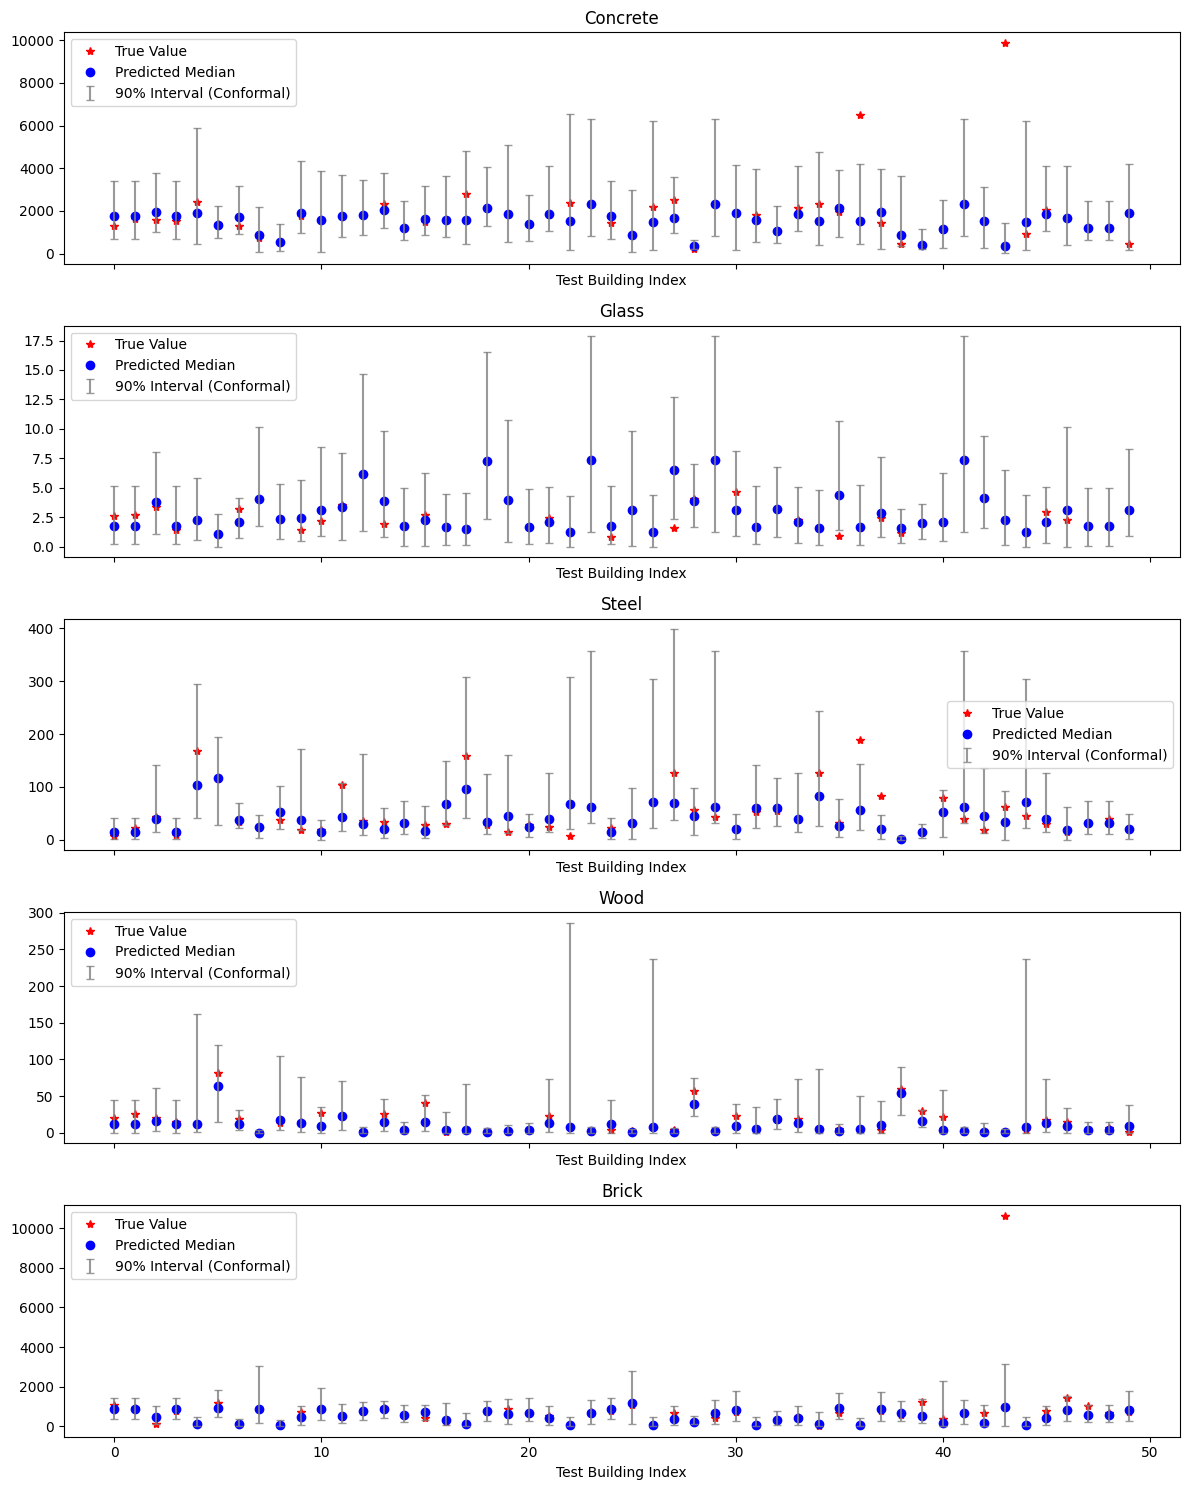

In [46]:
import matplotlib.pyplot as plt

# Validation split is used as calibration data for split-conformal intervals.
y_val_df = data["y_val_raw_df"].copy()
y_val_mask = data["y_val_mask"].cpu().numpy()
conformal_bundle = fit_conformal_qhats(
    model,
    data["X_val"],
    y_val_df,
    y_val_mask,
    alpha=0.10,
)
conformal_qhats = conformal_bundle["qhats"]
print("Conformal qhats:", conformal_qhats)

y_test_df = data["y_test_raw_df"].copy()
y_test_mask = data["y_test_mask"].cpu().numpy()

# Predict calibrated ranges for the first 50 buildings in the test set
X_test_first50 = data["X_test"][:50]
pred_ranges = predict_material_ranges(
    model,
    X_test_first50,
    conformal_qhats=conformal_qhats,
)

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
x_idx = np.arange(50)

for i, material in enumerate(y_cols):
    ax = axes[i]
    y_true = np.array(y_test_df[material].iloc[:50].to_numpy(dtype=float), copy=True)
    observed = y_test_mask[:50, i].astype(bool)
    y_true[~observed] = np.nan

    y_med = pred_ranges[material]["p50"]
    y_low = pred_ranges[material]["p5"]
    y_high = pred_ranges[material]["p95"]

    ax.plot(x_idx, y_true, "r*", label="True Value")
    ax.plot(x_idx, y_med, "bo", label="Predicted Median")
    ax.errorbar(
        x_idx,
        y_med,
        yerr=[y_med - y_low, y_high - y_med],
        fmt="none",
        ecolor="gray",
        alpha=0.8,
        capsize=3,
        label="90% Interval (Conformal)",
    )

    ax.set_title(material)
    ax.set_xlabel("Test Building Index")
    ax.legend()

plt.tight_layout()
plt.show()

In [49]:
# Print model performance on the full test set
# Uses conformal calibration if Cell 9 has been executed.
conformal_qhats = conformal_bundle["qhats"] if "conformal_bundle" in globals() else None
if conformal_qhats is None:
    print("Running without conformal calibration (execute Cell 9 first to calibrate).")
else:
    print("Running with conformal calibration from validation split.")

evaluate_mdn(
    model,
    data["X_test"],
    y_test_df,
    y_test_mask=data["y_test_mask"].cpu().numpy(),
    conformal_qhats=conformal_qhats,
)

Running with conformal calibration from validation split.
Concrete: MAE = 563.9382, 90% Coverage = 89.00%, MPIW = 3029.9292, MPIW/Mean = 2.0969, Winkler Score = 4373.8967
Glass: MAE = 1.3473, 90% Coverage = 92.51%, MPIW = 6.2365, MPIW/Mean = 2.0195, Winkler Score = 9.0242
Steel: MAE = 18.0859, 90% Coverage = 94.69%, MPIW = 118.3575, MPIW/Mean = 2.6942, Winkler Score = 179.1892
Wood: MAE = 8.6602, 90% Coverage = 95.24%, MPIW = 49.5012, MPIW/Mean = 2.5704, Winkler Score = 65.8120
Brick: MAE = 273.9245, 90% Coverage = 92.45%, MPIW = 1229.4255, MPIW/Mean = 1.7714, Winkler Score = 2070.6560


In [48]:
import joblib
import json

joblib.dump(data["preprocessor"], "preprocessor.joblib")
torch.save(model.state_dict(), "mdn_model_weights.pth")

with open("best_mdn_hparams.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print("Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json")

Saved preprocessor.joblib, mdn_model_weights.pth, and best_mdn_hparams.json


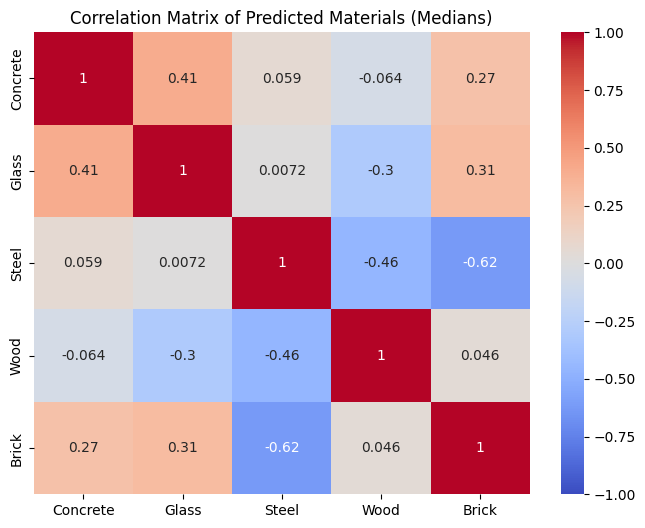

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch

# 1. Extract the predicted medians (q50 is at index 1) from the test set
model.eval()
with torch.no_grad():
    preds = model(data["X_test"]).cpu().numpy()
    
# preds shape is [batch_size, 5_materials, 3_quantiles]
predicted_medians = preds[:, :, 1] 

# 2. Convert to DataFrame
material_names = ["Concrete", "Glass", "Steel", "Wood", "Brick"]
df_preds = pd.DataFrame(predicted_medians, columns=material_names)

# 3. Calculate and plot Spearman correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df_preds.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Predicted Materials (Medians)")
plt.show()

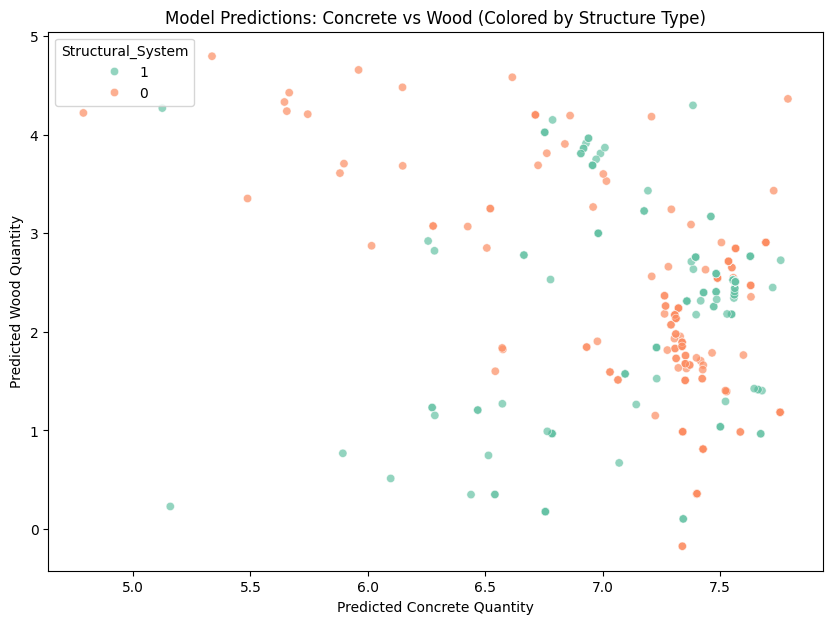

In [55]:
# Rebuild raw test features with the same split logic so we can color by structure type.
raw_df = pd.read_excel("Integrated_MI_database.xlsx")
raw_df["Construction period"] = pd.to_numeric(raw_df["Construction period"], errors="coerce")
raw_df = raw_df.dropna(subset=X_cols).reset_index(drop=True)

raw_target_mask_df = raw_df[y_cols].notna()
raw_df = raw_df.loc[
    raw_target_mask_df.sum(axis=1) >= MIN_OBSERVED_TARGETS
].reset_index(drop=True)

X_all_raw = raw_df[X_cols].copy()
y_all_raw = raw_df[y_cols].copy()
y_all_mask = y_all_raw.notna().to_numpy(dtype=bool)

split_data = train_test_split(
    X_all_raw,
    y_all_raw,
    y_all_mask,
    test_size=0.30,
    random_state=SEED,
)
X_train_raw, X_temp_raw, y_train_raw_df, y_temp_raw_df, y_train_mask, y_temp_mask = split_data

split_temp = train_test_split(
    X_temp_raw,
    y_temp_raw_df,
    y_temp_mask,
    test_size=0.50,
    random_state=SEED,
)
X_val_raw, X_test_raw, y_val_raw_df, y_test_raw_df, y_val_mask, y_test_mask = split_temp

test_raw_df = X_test_raw.reset_index(drop=True)

structural_col = "Hybrid Structure"
if structural_col not in test_raw_df.columns:
    raise KeyError(f"Column '{structural_col}' not found in raw test features.")

df_preds = df_preds.copy()
df_preds["Structural_System"] = test_raw_df[structural_col].astype(str).values

# Plot Concrete vs Wood, colored by structure type
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_preds,
    x="Concrete",
    y="Wood",
    hue="Structural_System",
    palette="Set2",
    alpha=0.7,
)
plt.title("Model Predictions: Concrete vs Wood (Colored by Structure Type)")
plt.xlabel("Predicted Concrete Quantity")
plt.ylabel("Predicted Wood Quantity")

# Optional for heavy-tailed distributions:
# plt.xscale("log")
# plt.yscale("log")

plt.show()

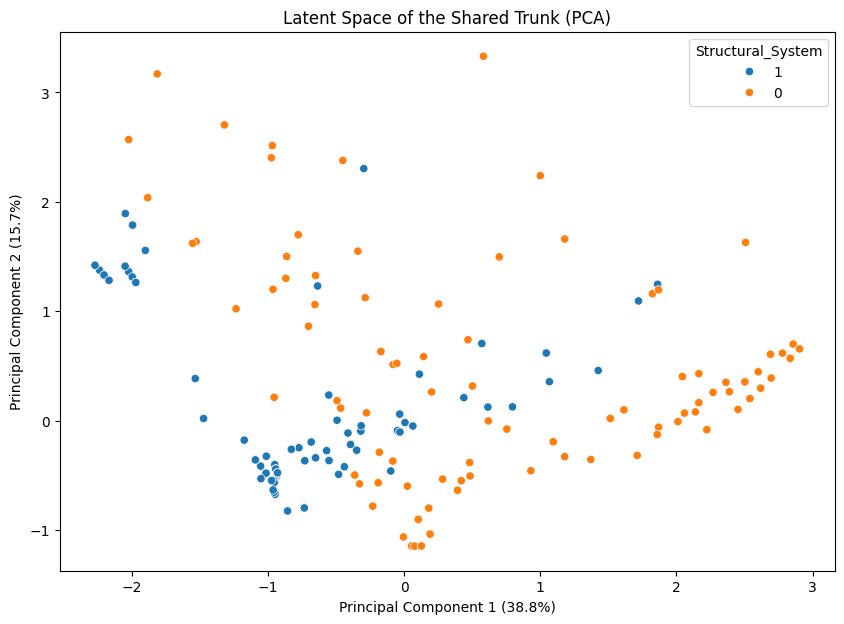

In [59]:
from sklearn.decomposition import PCA

# 1. Extract the shared representations from the trunk network
with torch.no_grad():
    shared_features = model.trunk(data["X_test"]).cpu().numpy()

# 2. Reduce the high-dimensional features to 2D using PCA
pca = PCA(n_components=2)
trunk_pca = pca.fit_transform(shared_features)

# 3. Resolve structure labels safely
if "test_raw_df" in globals() and "Hybrid Structure" in test_raw_df.columns:
    structure_labels = test_raw_df["Hybrid Structure"].astype(str).values
elif "df_preds" in globals() and "Structural_System" in df_preds.columns:
    structure_labels = df_preds["Structural_System"].astype(str).values
else:
    raise KeyError(
        "Could not find structure labels. Run Cell 13 first to build test_raw_df/df_preds."
    )

# 4. Create a DataFrame for plotting
df_pca = pd.DataFrame(
    {
        "PCA_1": trunk_pca[:, 0],
        "PCA_2": trunk_pca[:, 1],
        "Structural_System": structure_labels,
    }
)

# 5. Plot the latent space
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x="PCA_1",
    y="PCA_2",
    hue="Structural_System",
    palette="tab10",
)
plt.title("Latent Space of the Shared Trunk (PCA)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.show()